# 06k — Discreteness-fairness levers on representation quality (G=28)

**Kickoff K** of the barycenter arc — a *fairness follow-up* to F·S2. The benchmarked averagers split into
**two families** by how they treat the discrete symbol space (`BARYCENTER_METHOD_DISCRETENESS.md`,
RESULTS_HANDOFF §18.4): **Family A** stays native-categorical; **Family B** embeds each symbol as its `D_G`
row, averages real vectors, and decodes to a symbol only at the end. Lever 1 (documenting the split) is done;
this notebook previews the two remaining **algorithmic** levers, **additively and ablation-reported** (existing
methods/results unchanged — no cherry-picked winner):

- **Lever 2 — ground-cost-consistent decode** (`decode={'euclidean','dg'}`). rTWE (the harness yardstick)
  uses a *direct* `D_G[a,b]` ground cost, so the consistent decode of a mean profile `m` is `argmin_c m[c]`
  (the vocabulary-restricted 1-medoid under `D_G`) — different from the current Euclidean nearest-`D_G`-row.
  Reported as an **Euclidean-vs-`D_G` ablation** on the same continuous barycenter (same seeds ⇒ only the
  decode differs). For `fgw_onehot`, `dg` is the barycentric ground-cost projection `argmin_c (D_G @ p)[c]`.
- **Lever 3 — per-iteration re-discretised categorical variants** (`dba_dtw_cat`, `ssg_cat`,
  `soft_dtw_bary_cat`). Keep the Family-B reference a **valid symbol string every iteration** (like the paper's
  mode-DBA precedent `barycenter_mode_dba`, but mean-then-snap rather than a hard vote). Reported as a
  **continuous-vs-categorical ablation** *alongside* the standard once-at-the-end methods.

**This is a GATED preview.** L=128, few inits, reduced `dba` budget. The full-length (L≈5162) / full-cohort /
full-budget run is a **`pomme` hand-off** (stub at the end — not run locally). The point is
**faithfulness/fairness, not a new winner** — both decodes and both variants are reported per axis.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')  # fork-safe rTWE under nbconvert
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from smartflat.utils.utils_io import get_data_root
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter import visualization as viz
from smartflat.features.symbolic_barycenter.baselines import (
    default_baseline_methods, barycenter_mode_dba, barycenter_dba_dtw, dist_rtwe,
    fgw_methods, softdtw_ssg_methods, discreteness_lever_methods)
from smartflat.features.symbolic_barycenter.barycenter_quality import (
    score_barycenter_quality, quality_table)
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance
pd.set_option('display.width', 220, 'display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110

OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28')
EXP = os.path.join(OUT, 'experiments'); os.makedirs(EXP, exist_ok=True)

# Hyperparameters (thesis G=28), shared length gate, and the gated lever budgets.
L, NU, LMBDA, RS, N_INITS = 128, 1e-4, 0.1, 42, 2
DBA_IT, SDTW_IT, SSG_IT = 6, 10, 10        # gated iteration budgets (dba is O(L^2) pure-numpy -> low)
CAT_ROUNDS, CAT_INNER = 6, 8               # Lever-3 outer/inner loop for the tslearn cat variants
print('output dir:', EXP)

output dir: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/experiments


In [2]:
# Canonical G=28 cohort + ground cost via E's shared loaders (06c Cells 2-3).
# Lock-step scoring needs a rectangular length -> upsample to L=128 (gates the O(L^2) dba build).
# Full L~5162 stays deferred to pomme.
df, X, labels = vocab.load_g28_cohort(upsample_to=L)
D_G = vocab.build_g28_ground_cost(); G = D_G.shape[0]
code_dict = json.load(open(os.path.join(OUT, 'category_codes.json')))
code_to_label = {int(v): k for k, v in code_dict.items()}
print('cohort:', df.groupby('pathologie').size().to_dict(), '| G =', G, '| X', X.shape)

cohort: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59} | G = 28 | X (120, 128)


## (1) Registry — Family-B anchors + the lever variants

The **anchors** are the standard once-at-the-end Family-B methods (`dba_dtw`, `soft_dtw_bary`, `ssg`,
`fgw_onehot`) plus two reference points (`wasserstein` = the winning frequency histogram; `tw_twe_mode` = the
paper's mode-DBA, the categorical precedent). `discreteness_lever_methods` adds the seven new variants:
the `*_dg` Lever-2 decodes and the `*_cat` Lever-3 categorical builds. **Anchors and lever variants share
identical hyperparameters + seeds**, so each `*_dg` shares its Euclidean sibling's continuous barycenter and
differs *only* in the decode — a clean ablation.

In [3]:
base = default_baseline_methods(D_G, nu=NU, lmbda=LMBDA)
def _rtwe_dist(seq, b):
    return dist_rtwe(seq, b, D_G, nu=NU, lmbda=LMBDA)
anchors = {
    'wasserstein': base['wasserstein'],                              # symbol-frequency histogram (reference)
    'tw_twe_mode': {'build': lambda Xg, s: barycenter_mode_dba(Xg, D_G, nu=NU, lmbda=LMBDA, max_iter=10),
                    'distance': _rtwe_dist},                          # paper mode-DBA (categorical precedent)
    'dba_dtw':     {'build': lambda Xg, s: barycenter_dba_dtw(Xg, D_G, max_iters=DBA_IT, random_state=s),
                    'distance': _rtwe_dist},                          # Family-B DBA, Euclidean decode @ end
}
_ss = softdtw_ssg_methods(D_G, nu=NU, lmbda=LMBDA, sdtw_max_iter=SDTW_IT, ssg_max_iter=SSG_IT)
anchors['soft_dtw_bary'] = _ss['soft_dtw_bary']                       # Euclidean decode @ end
anchors['ssg'] = _ss['ssg']                                          # Euclidean decode @ end
anchors['fgw_onehot'] = fgw_methods(D_G, n_nodes=L, alpha=0.5, nu=NU, lmbda=LMBDA)['fgw_onehot']

levers = discreteness_lever_methods(D_G, nu=NU, lmbda=LMBDA, dba_max_iters=DBA_IT,
                                    sdtw_max_iter=SDTW_IT, ssg_max_iter=SSG_IT, fgw_n_nodes=L,
                                    cat_rounds=CAT_ROUNDS, cat_inner_iter=CAT_INNER)
methods = {**anchors, **levers}
print('=== GATED PREVIEW (NOT the scale run) ===')
print(f'  L = {L} (full-length L~5162 -> O(L^2) dba build: DEFERRED to pomme); n_inits = {N_INITS}')
print(f'  gated budgets: dba_max_iters={DBA_IT}, sdtw/ssg max_iter={SDTW_IT}/{SSG_IT},'
      f' cat rounds/inner={CAT_ROUNDS}/{CAT_INNER}')
print('  Lever 2 (decode): *_dg = argmin_c m[c] (D_G 1-medoid); fgw_onehot_dg = barycentric (D_G @ p) argmin')
print('  Lever 3 (categorical): *_cat re-discretise every iteration (dg snap), like mode-DBA (mean-then-snap)')
print('  cohort = local G=28 upsampled subset (full-cohort scale run: DEFERRED to pomme)')
print('scored:', list(methods))

=== GATED PREVIEW (NOT the scale run) ===
  L = 128 (full-length L~5162 -> O(L^2) dba build: DEFERRED to pomme); n_inits = 2
  gated budgets: dba_max_iters=6, sdtw/ssg max_iter=10/10, cat rounds/inner=6/8
  Lever 2 (decode): *_dg = argmin_c m[c] (D_G 1-medoid); fgw_onehot_dg = barycentric (D_G @ p) argmin
  Lever 3 (categorical): *_cat re-discretise every iteration (dg snap), like mode-DBA (mean-then-snap)
  cohort = local G=28 upsampled subset (full-cohort scale run: DEFERRED to pomme)
scored: ['wasserstein', 'tw_twe_mode', 'dba_dtw', 'soft_dtw_bary', 'ssg', 'fgw_onehot', 'dba_dtw_dg', 'soft_dtw_bary_dg', 'ssg_dg', 'fgw_onehot_dg', 'dba_dtw_cat', 'ssg_cat', 'soft_dtw_bary_cat']


## (2) Full methods × quality-metric table (L=128, gated budget)

The unchanged §17 harness scores every variant on the common **rTWE within-group inertia** yardstick plus
frequency fidelity, structure preservation, entropy, distinct-symbol and segment counts. The `family` column
tags how each treats discreteness (A / B / the new B-decode / B→categorical variants).

In [4]:
res = score_barycenter_quality(X, labels, methods, D_G, n_inits=N_INITS, random_state=RS)
q = quality_table(res)
q_show = q.drop(columns=['stability_inertia_rtwe', 'stability_histogram'])
# Discreteness family (see BARYCENTER_METHOD_DISCRETENESS.md / RESULTS_HANDOFF §18.4, §20):
FAMILY = {'wasserstein': 'A (freq only)', 'tw_twe_mode': 'A',
          'dba_dtw': 'B', 'soft_dtw_bary': 'B', 'ssg': 'B', 'fgw_onehot': 'B',
          'dba_dtw_dg': 'B (D_G decode)', 'soft_dtw_bary_dg': 'B (D_G decode)',
          'ssg_dg': 'B (D_G decode)', 'fgw_onehot_dg': 'B (D_G decode)',
          'dba_dtw_cat': 'B->cat (per-iter)', 'ssg_cat': 'B->cat (per-iter)',
          'soft_dtw_bary_cat': 'B->cat (per-iter)'}
q_show.insert(0, 'family', [FAMILY.get(m, '?') for m in q_show.index])
q.to_csv(os.path.join(EXP, 'barycenter_quality_discreteness_levers_L128.csv'))
grp_H = np.mean([
    -(lambda p: (p[p>0]*np.log2(p[p>0])).sum())(np.bincount(X[labels==g].ravel(), minlength=G)/(labels==g).sum()/L)
    for g in np.unique(labels)])
print(f'group-sequence entropy reference: ~{grp_H:.2f} bits')
display(q_show.round(3))

/tmp/ipykernel_2036984/3104164848.py:8: DeprecationWarning: barycenter_dba_dtw(max_iters=...) is deprecated; use max_iter=...
  'dba_dtw':     {'build': lambda Xg, s: barycenter_dba_dtw(Xg, D_G, max_iters=DBA_IT, random_state=s),


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/tmp/ipykernel_2036984/3104164848.py:8: DeprecationWarning: barycenter_dba_dtw(max_iters=...) is deprecated; use max_iter=...
  'dba_dtw':     {'build': lambda Xg, s: barycenter_dba_dtw(Xg, D_G, max_iters=DBA_IT, random_state=s),


...

/tmp/ipykernel_2036984/3104164848.py:8: DeprecationWarning: barycenter_dba_dtw(max_iters=...) is deprecated; use max_iter=...
  'dba_dtw':     {'build': lambda Xg, s: barycenter_dba_dtw(Xg, D_G, max_iters=DBA_IT, random_state=s),


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


group-sequence entropy reference: ~3.78 bits


metric,family,inertia_rtwe,inertia_native,freq_fidelity,struct_preservation,entropy_bits,n_distinct,n_segments
method,,,,,,,,
dba_dtw,B,44.752,44.752,0.110,2.817,3.147,15.167,61.167
dba_dtw_cat,B->cat (per-iter),43.908,43.908,0.122,2.602,3.053,13.500,55.167
dba_dtw_dg,B (D_G decode),43.358,43.358,0.114,2.655,3.043,13.500,58.667
fgw_onehot,B,77.393,77.393,0.033,3.494,3.554,18.667,117.000
fgw_onehot_dg,B (D_G decode),77.375,77.375,0.038,3.469,3.573,18.667,117.167
soft_dtw_bary,B,47.080,-58.102,0.170,2.748,3.092,12.000,23.667
soft_dtw_bary_cat,B->cat (per-iter),45.308,-59.774,0.168,2.516,2.977,10.333,21.333
soft_dtw_bary_dg,B (D_G decode),45.832,-59.068,0.166,2.562,2.952,10.000,21.667
ssg,B,45.825,45.825,0.125,2.952,3.314,15.667,65.000


## (3) Ablation A — decode: Euclidean vs `D_G` (per axis, both ways)

Each Family-B method scored twice with an **identical continuous barycenter**, differing only in the final
decode. `dg` = `argmin_c m[c]` (ground-cost 1-medoid, the geometry rTWE scores in); `fgw_onehot` `dg` =
barycentric `argmin_c (D_G @ p)[c]`. **No cherry-picked winner** — read both columns per axis.

In [5]:
AXES = ['inertia_rtwe', 'freq_fidelity', 'struct_preservation', 'entropy_bits', 'n_distinct', 'n_segments']
DECODE_PAIRS = [('dba_dtw', 'dba_dtw_dg'), ('soft_dtw_bary', 'soft_dtw_bary_dg'),
                ('ssg', 'ssg_dg'), ('fgw_onehot', 'fgw_onehot_dg')]
rows = []
for eu, dg in DECODE_PAIRS:
    for name, lbl in [(eu, 'euclidean'), (dg, 'D_G')]:
        r = {'method': eu, 'decode': lbl}
        r.update({ax: q.loc[name, ax] for ax in AXES})
        rows.append(r)
decode_tbl = pd.DataFrame(rows).set_index(['method', 'decode'])[AXES]
display(decode_tbl.round(3))
# per-axis delta (D_G - euclidean) for a quick both-ways read
delta = (decode_tbl.xs('D_G', level='decode') - decode_tbl.xs('euclidean', level='decode'))
print('per-axis (D_G - euclidean) delta -- neither decode wins on all axes:')
display(delta.round(3))

inertia_rtwe  freq_fidelity  struct_preservation  entropy_bits  n_distinct  n_segments
method        decode                                                                                           
dba_dtw       euclidean        44.752          0.110                2.817         3.147      15.167      61.167
              D_G              43.358          0.114                2.655         3.043      13.500      58.667
soft_dtw_bary euclidean        47.080          0.170                2.748         3.092      12.000      23.667
              D_G              45.832          0.166                2.562         2.952      10.000      21.667
ssg           euclidean        45.825          0.125                2.952         3.314      15.667      65.000
              D_G              44.038          0.136                2.741         3.103      13.333      59.667
fgw_onehot    euclidean        77.393          0.033                3.494         3.554      18.667     117.000
              D_G              77.375          0.038                3.469         3.573      18.667     117.167

per-axis (D_G - euclidean) delta -- neither decode wins on all axes:


,inertia_rtwe,freq_fidelity,struct_preservation,entropy_bits,n_distinct,n_segments
method,,,,,,
dba_dtw,-1.393,0.004,-0.162,-0.104,-1.667,-2.500
soft_dtw_bary,-1.248,-0.003,-0.186,-0.140,-2.000,-2.000
ssg,-1.787,0.011,-0.211,-0.211,-2.333,-5.333
fgw_onehot,-0.018,0.004,-0.025,0.019,0.000,0.167


## (4) Ablation B — continuous (snap@end) vs categorical (per-iteration)

The Lever-3 `*_cat` variants keep the reference a valid symbol string throughout (mean-then-snap each
iteration), vs the standard continuous methods that snap once at the end. Reported **alongside**, per axis —
whether staying categorical helps or hurts is an honest per-axis question, not a winner.

In [6]:
CAT_PAIRS = [('dba_dtw', 'dba_dtw_cat'), ('ssg', 'ssg_cat'), ('soft_dtw_bary', 'soft_dtw_bary_cat')]
rows = []
for cont, cat in CAT_PAIRS:
    for name, lbl in [(cont, 'continuous (snap@end)'), (cat, 'categorical (per-iter)')]:
        r = {'method': cont, 'variant': lbl}
        r.update({ax: q.loc[name, ax] for ax in AXES})
        rows.append(r)
cat_tbl = pd.DataFrame(rows).set_index(['method', 'variant'])[AXES]
display(cat_tbl.round(3))
delta_c = (cat_tbl.xs('categorical (per-iter)', level='variant')
           - cat_tbl.xs('continuous (snap@end)', level='variant'))
print('per-axis (categorical - continuous) delta -- honest both-ways read:')
display(delta_c.round(3))

inertia_rtwe  freq_fidelity  struct_preservation  entropy_bits  n_distinct  n_segments
method        variant                                                                                                       
dba_dtw       continuous (snap@end)         44.752          0.110                2.817         3.147      15.167      61.167
              categorical (per-iter)        43.908          0.122                2.602         3.053      13.500      55.167
ssg           continuous (snap@end)         45.825          0.125                2.952         3.314      15.667      65.000
              categorical (per-iter)        44.345          0.137                2.703         3.095      13.333      60.500
soft_dtw_bary continuous (snap@end)         47.080          0.170                2.748         3.092      12.000      23.667
              categorical (per-iter)        45.308          0.168                2.516         2.977      10.333      21.333

per-axis (categorical - continuous) delta -- honest both-ways read:


,inertia_rtwe,freq_fidelity,struct_preservation,entropy_bits,n_distinct,n_segments
method,,,,,,
dba_dtw,-0.844,0.013,-0.215,-0.094,-1.667,-6.000
ssg,-1.480,0.012,-0.249,-0.219,-2.333,-4.500
soft_dtw_bary,-1.772,-0.002,-0.232,-0.115,-1.667,-2.333


## (5) Chronograms — eyeballing the decode / categorical effect

`dba_dtw` (the exact-medoid case) under the three treatments: Euclidean-decode continuous, `D_G`-decode
continuous, and per-iteration categorical. Any visible difference is the discreteness lever at work.

/tmp/ipykernel_2036984/3104164848.py:8: DeprecationWarning: barycenter_dba_dtw(max_iters=...) is deprecated; use max_iter=...
  'dba_dtw':     {'build': lambda Xg, s: barycenter_dba_dtw(Xg, D_G, max_iters=DBA_IT, random_state=s),


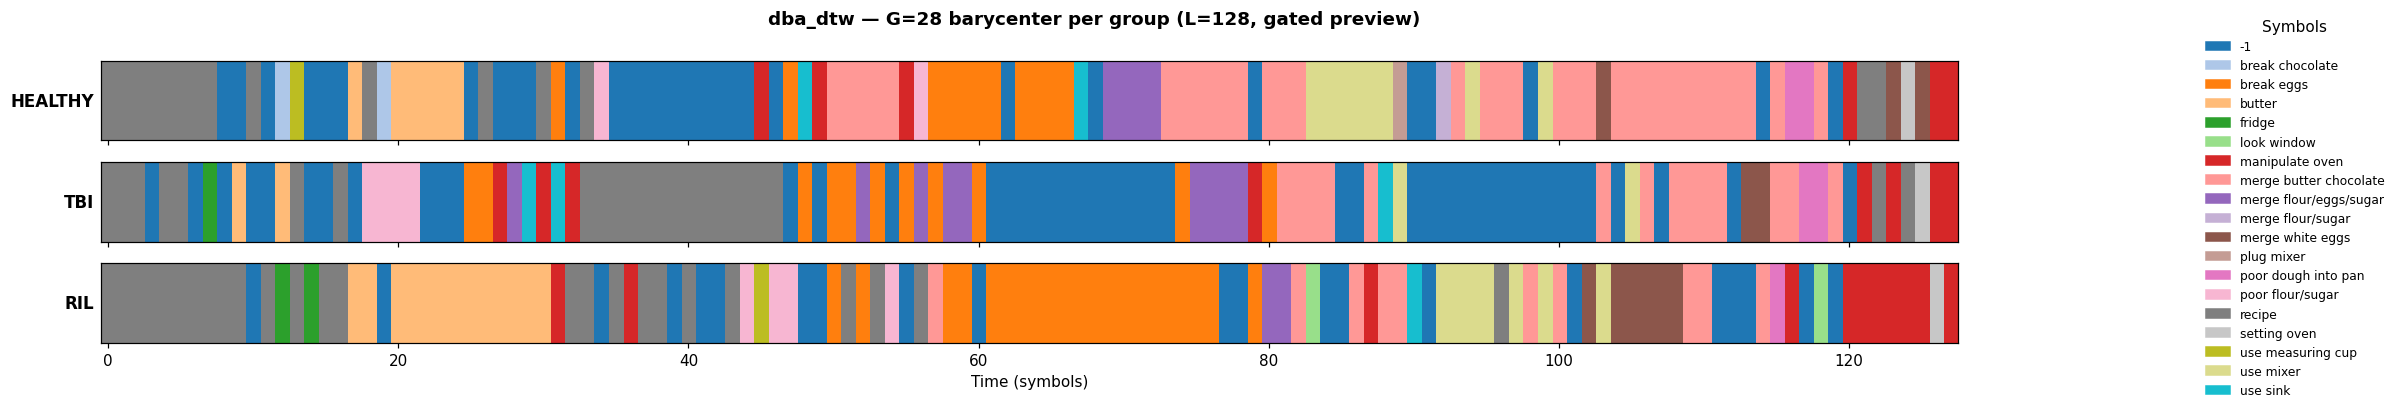

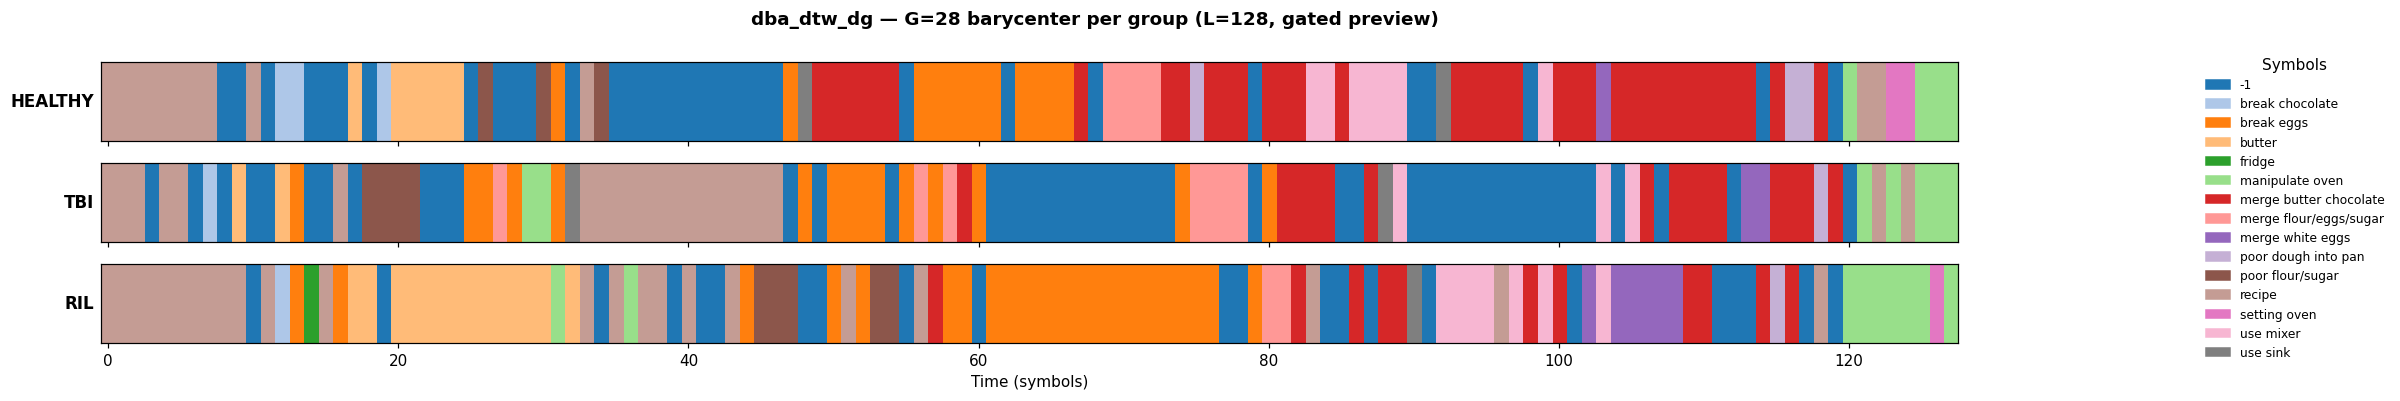

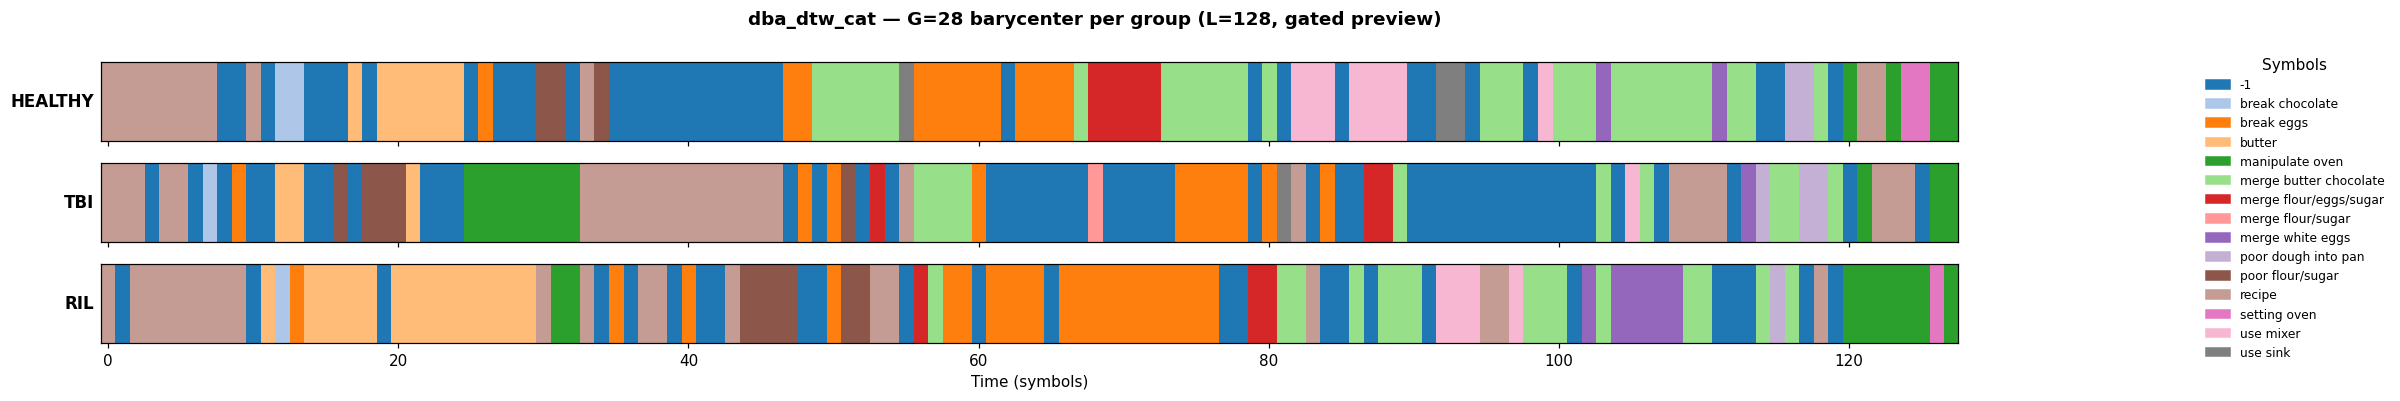

In [7]:
CHRONO = ['dba_dtw', 'dba_dtw_dg', 'dba_dtw_cat']
groups = ['HEALTHY', 'TBI', 'RIL']
for name in CHRONO:
    spec = methods[name]
    barys = {g: np.asarray(spec['build'](X[labels == g].astype(int), RS)).astype(int) for g in groups}
    fig = viz.plot_cohort_barycenters(barys, groups=groups, code_to_label=code_to_label,
                                      title=f'{name} — G=28 barycenter per group (L={L}, gated preview)')
    fig.savefig(os.path.join(EXP, f'chronogram_lever_{name}.png'), dpi=150, bbox_inches='tight')
    display(fig); plt.close(fig)

## (6) Scale hand-off — run at full length / full cohort on `pomme`

The cell below is a **stub — NOT run locally**. It documents the full-length (L≈5162) / full-cohort /
full-budget invocation for the `pomme` server (dominant cost is the O(L^2) `dba` build).

In [8]:
# --- run at scale on pomme (NOT run locally) ---
# Full-length (no upsample -> ragged native L up to ~5162) + full G=28 cohort + full budgets.
#
# from smartflat.features.symbolic_barycenter import vocab
# from smartflat.features.symbolic_barycenter.baselines import discreteness_lever_methods
# from smartflat.features.symbolic_barycenter.barycenter_quality import (
#     score_barycenter_quality, quality_table)
#
# L_FULL = 5162                       # or per-group native max length
# df, X, labels = vocab.load_g28_cohort(upsample_to=L_FULL)   # rectangular for lock-step scoring
# D_G = vocab.build_g28_ground_cost()
# methods = discreteness_lever_methods(D_G, nu=1e-4, lmbda=0.1, dba_max_iters=30,
#                                      sdtw_max_iter=50, ssg_max_iter=30, fgw_n_nodes=L_FULL)
# res = score_barycenter_quality(X, labels, methods, D_G, n_inits=3, random_state=42)
# quality_table(res).to_csv('barycenter_quality_discreteness_levers_FULL.csv')
print('pomme scale-run stub — not executed locally')

pomme scale-run stub — not executed locally


## Summary (→ `RESULTS_HANDOFF_barycenters.md` §20)

Two algorithmic discreteness-fairness levers now ship **additively** through the unchanged §17 harness:
a ground-cost (`D_G`) decode knob and per-iteration categorical variants — reported as **decode** and
**continuous-vs-categorical** ablations. The honest frame is unchanged from §17–§19: *representativeness, not
a race*; both decodes and both variants are reported per axis, with no cherry-picked winner. Full-length /
full-cohort numbers are a `pomme` hand-off.